## Assignment 4

This assignment asks you to use resources at hand to apply module 6 - Linear Regression to several sets of data.

## Learning Outcomes

- Exploratory analysis for regression
- Understand difference between linear and non-linear models
- Carry out OLS regression model
- Evaluate model


**Question 1**

* For each data set in Assignment4_linear_regression_data.xlsx:

- Create a scatter plot and visually decide if a linear model is appropriate (a matrix scatter plot will would be most efficient).

* If the relation is not linear, transform the data accordingly. 
 - Try logarithm, exponential, square root, square, etc., for Y and/or X until you see a linear relation.  You only need to report what is the transformation chosen, not all the attempts. 
 Note:  most of the time, you can guess visually. A systematic way is to create a matrix scatter plot of the different transformations.  A generic way we did not cover is to use a Box-Cox transformation. 
 
* Create an OLS model for the original and transformed data if required. 
 - Evaluate if the OLS assumptions are met: normality of errors centered around zero, equal variance, etc..., for the original data and transformed data if appropriate. 

 - Comment how the transformation impacted the different assumptions. (This should be done only by looking at the output diagnostic charts created by the software)
 - If datasets have outliers, remove the outliers and see the effect in the model (slope, intercept and R-square)


The output of the assignment should be: 

- OLS full report for the original and transformed data if appropriate (only two datasets should need transformation).

- A short comment on the validity of the linear assumptions for the original and transformed data set when appropriate (it should not need to be longer than a couple of sentences).

- An interpretation of the slope and intercept in relation to the original data, i.e. if the model is linear [intercept value] is the expected value when the independent variable is zero, etc.).  If the model is not linear, you need to transform the equation back to its original form.  

Check out the following if you need further guidance:
http://www.bzst.com/2009/09/interpreting-log-transformed-variables.html

https://stats.idre.ucla.edu/other/mult-pkg/faq/general/faqhow-do-i-interpret-a-regression-model-when-some-variables-are-log-transformed/

https://stats.idre.ucla.edu/sas/faq/how-can-i-interpret-log-transformed-variables-in-terms-of-percent-change-in-linear-regression/

https://stats.stackexchange.com/questions/266722/interpretation-of-linear-regression-results-where-dependent-variable-is-transfor

- If the dataset have outliers, determine if the outlier have leverage or not by comparing the OLS with and without the outlier.


In [1]:
#your work here

In [156]:
# import libraries
import numpy as np
import pandas as pd
from pandas import DataFrame, Series
import statsmodels.formula.api as sm
#import sklearn.linear_model as 
import scipy, scipy.stats
import matplotlib.pyplot as plt
from matplotlib.pyplot import scatter
from pandas.plotting import scatter_matrix
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
%matplotlib inline

In [256]:
# Get data on assignment 4
df = pd.read_excel('Assignment4_linear_regresion_data.xlsx', sheet_name=None)

Creating plot for sheet: Set 1


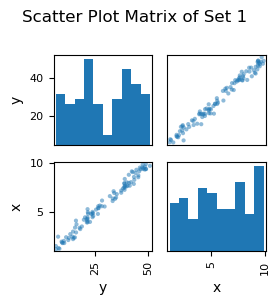

Creating plot for sheet: Set 2


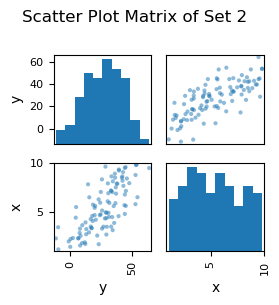

Creating plot for sheet: Set 3


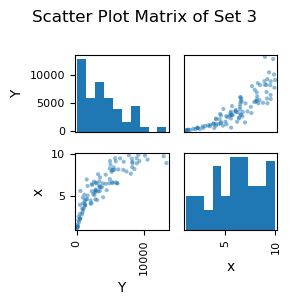

Creating plot for sheet: Set 4


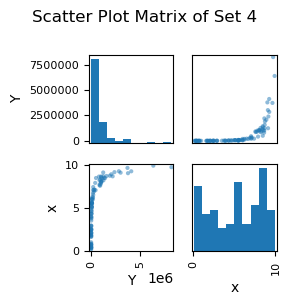

Creating plot for sheet: Set 5


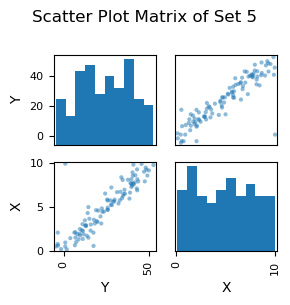

Creating plot for sheet: Set 6


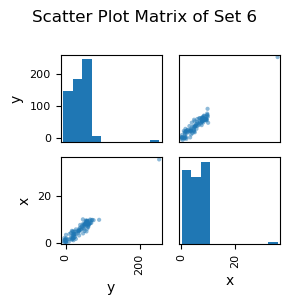

In [257]:

#loop the data and create plot; also seperate data in each tab to different dataframes
a=0
for sheet_name, sub_df in df.items():
    print(f"Creating plot for sheet: {sheet_name}")
    scatter_matrix(sub_df, figsize=(3, 3))
    plt.suptitle(f'Scatter Plot Matrix of {sheet_name}', y=1) 
    plt.tight_layout()
    plt.show()
    a=a+1
    globals()[f"set{a}_df"] = sub_df



'''If the relation is not linear, transform the data accordingly.
Try logarithm, exponential, square root, square, etc., 
for Y and/or X until you see a linear relation. You only need to report what is the transformation chosen, 
not all the attempts. Note: most of the time, you can guess visually. 
A systematic way is to create a matrix scatter plot of the different transformations. A generic way we did not cover is to use a Box-Cox transformation.'''

'''Assumptions of Linear Regression:

Linearity: Ensure there is a linear relationship between the independent variables and the dependent variable.
Independence: Ensure observations are independent of each other.
Homoscedasticity: Ensure constant variance of errors.
Normality of Errors: Ensure the residuals (errors) are normally distributed.'''


# data set 1 
1. Create a scatter plot and evaluate: A linear model is appropriate because:
    1. Linear Relationship: The scatter plot of x vs. y indicates a strong linear relationship, which is ideal for linear regression.
    2. Distribution: The histograms for both x and y show their respective distributions. They appear reasonably spread out without extreme skewness. 
2. Carry out OLS regression model:
    1. 97.9% of the variability in the dependent variable (y) is explained by the independent variable (x). This suggests a very strong linear relationship between x and y.
    2. Skewness: -0.536, Kurtosis: 2.988 Skewness close to zero indicates slight asymmetry; kurtosis around 3 suggests normal distribution of residuals.
3. Evaluate model: An interpretation of the slope and intercept in relation to the original data
    1. Intercept Coefficient: 0.238 p-value: 0.613 The intercept is not statistically significant, suggesting it may not be different from zero.
    2. Slope Coefficient: 4.9843 p-value: 0.000  The slope coefficient is highly significant, indicating a strong linear relationship between x and y.
    3. The intercept is the estimated y when x takes value 0, i.e. when the x is 0. The average y is 0.238. The slope indicates that, on average, when x increase 1, y increase about 4.9843 .
4. Residual plot meets conditions
    1. Nearly normal residuals (randomly scattered):The residuals appear to be randomly scattered around the horizontal line at zero.This indicates that the linear regression model is appropriate for the data.
    2. Homoscedasticity(Constant variability):The residuals have constant variance across all levels of x.
    3. Linearity (No Obvious Patterns): There are no clear patterns, such as curvature or systematic structure, in the residuals.This suggests that there are no major issues with non-linearity.
    4. Independent observations


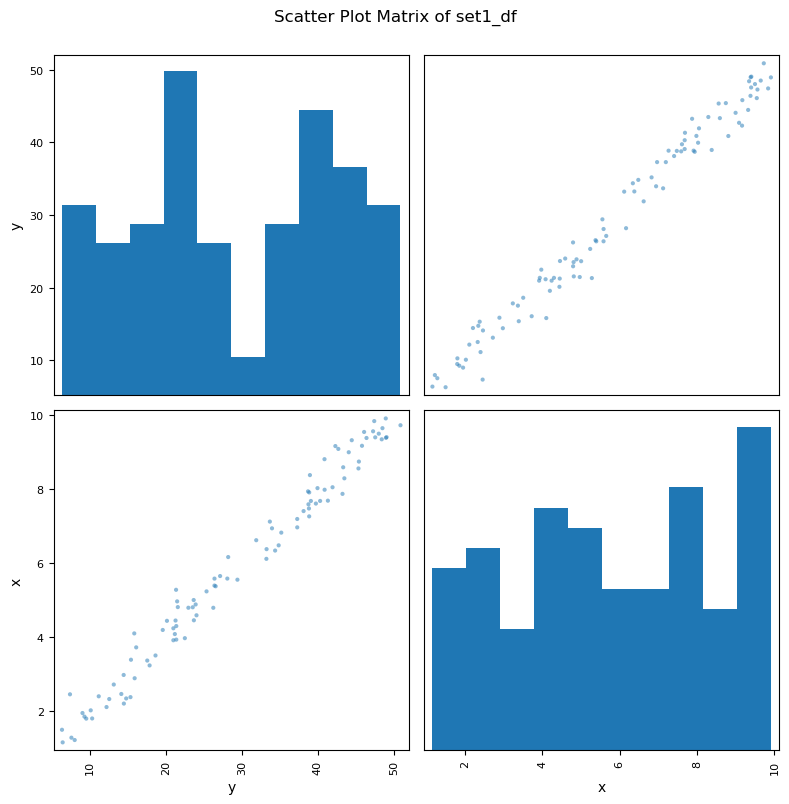

In [167]:
    scatter_matrix(set1_df, figsize=(8,8))
    plt.suptitle('Scatter Plot Matrix of set1_df', y=1) 
    plt.tight_layout()
    plt.show()

In [161]:
# OLS for original y option
import statsmodels.api as sm
x = set1_df[['x']]
y = set1_df['y']

# Add a constant to the independent variables matrix for intercept
x_add_const = sm.add_constant(x) # this add a constant of 1

# Fit OLS model
ols_model_1= sm.OLS(y, x_add_const).fit()

# model summary
ols_model_1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                     4579.
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           4.47e-84
Time:                        16:58:17   Log-Likelihood:                -206.03
No. Observations:                 100   AIC:                             416.1
Df Residuals:                      98   BIC:                             421.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2381      0.469      0.508      0.613      -0.693       1.169
x              4.9843      0.074     67.669      0.000       4.838       5.130
==============================================================================
Omnibus:                        4.971   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.083   Jarque-Bera (JB):                4.783
Skew:                          -0.536   Prob(JB):                       0.0915
Kurtosis:                       2.988   Cond. No.                         15.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

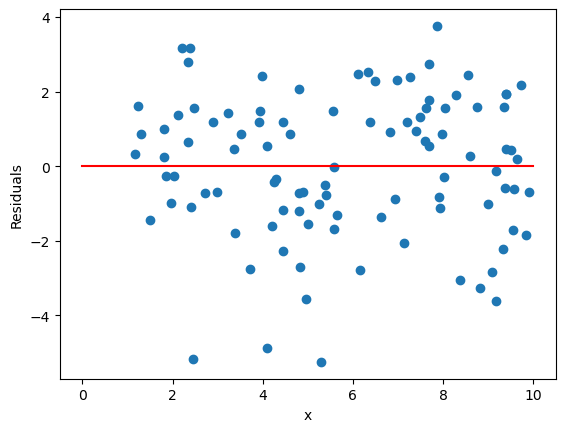

In [166]:
# Residual plot for original y option
scatter(x, y - ols_model_1.predict(x_add_const ))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')

plt.show() 

# data set 2 
1. Create a scatter plot and evaluate: A linear model is appropriate because:
    1. Linear Relationship: The scatter plot of x vs. y indicates a strong linear relationship, which is ideal for linear regression. Data set 2's data is more scattered than data set 1, so the R square won't be as high as data set 1.
    2. Distribution: The histograms for both x and y show their respective distributions. They appear reasonably spread out without extreme skewness. 
2. Carry out OLS regression model:
    1. 55.5% of the variability in the dependent variable (y) is explained by the independent variable (x). 
    2. Skewness: -0.065, Kurtosis: 3.045 Skewness close to zero indicates that the distribution is approximately symmetric around its mean; kurtosis around 3 suggests normal distribution of residuals.
3. Evaluate model: An interpretation of the slope and intercept in relation to the original data
    1. Intercept Coefficient: 1.0956 p-value: 0.668 The intercept is not statistically significant, suggesting it may not be different from zero.
    2. Slope Coefficient: 4.7774 p-value: 0.000  The slope coefficient is highly significant, indicating a strong linear relationship between x and y.
    3. The intercept is the estimated y when x takes value 0, i.e. when the x is 0. The average y is 1.0956. The slope indicates that, on average, when x increase 1, y increase about 4.7774 .
4. Residual plot meets conditions
    1. Nearly normal residuals (randomly scattered):The residuals appear to be randomly scattered around the horizontal line at zero.This indicates that the linear regression model is appropriate for the data.
    2. Homoscedasticity(Constant variability):The residuals have constant variance across all levels of x.
    3. Linearity (No Obvious Patterns): There are no clear patterns, such as curvature or systematic structure, in the residuals.This suggests that there are no major issues with non-linearity.
    4. Independent observations


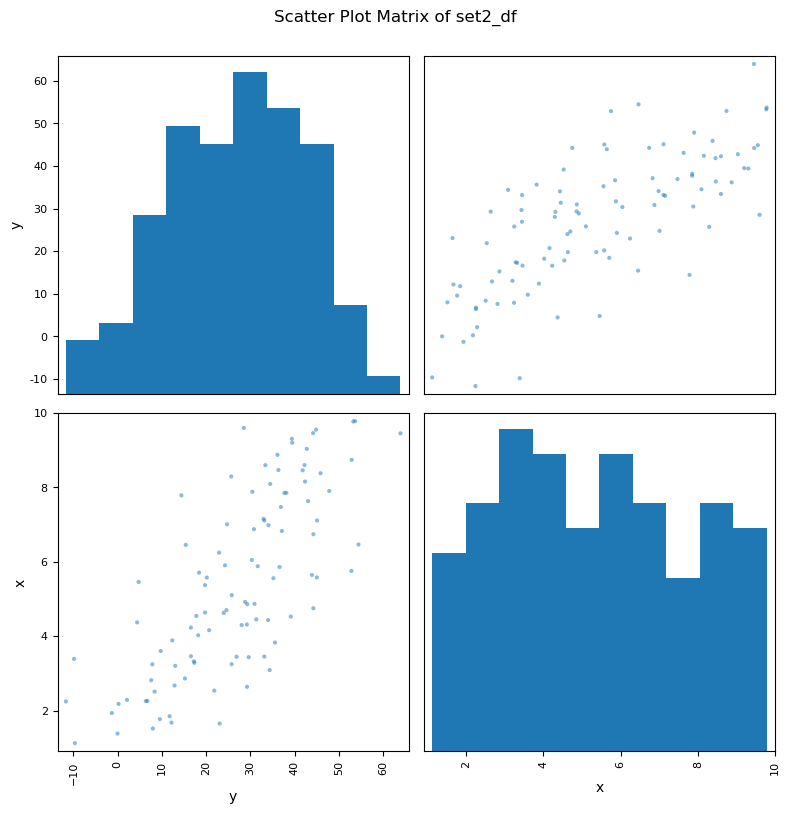

In [168]:
    scatter_matrix(set2_df, figsize=(8,8))
    plt.suptitle('Scatter Plot Matrix of set2_df', y=1) 
    plt.tight_layout()
    plt.show()

In [169]:
# OLS for original y option
import statsmodels.api as sm
x = set2_df[['x']]
y = set2_df['y']

# Add a constant to the independent variables matrix for intercept
x2_add_const = sm.add_constant(x) # this add a constant of 1

# Fit OLS model
ols_model_2= sm.OLS(y, x2_add_const).fit()

# model summary
ols_model_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.555
Model:                            OLS   Adj. R-squared:                  0.551
Method:                 Least Squares   F-statistic:                     122.4
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           6.11e-19
Time:                        17:22:25   Log-Likelihood:                -375.73
No. Observations:                 100   AIC:                             755.5
Df Residuals:                      98   BIC:                             760.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0956      2.547      0.430      0.668      -3.958       6.149
x              4.7774      0.432     11.062      0.000       3.920       5.634
==============================================================================
Omnibus:                        0.254   Durbin-Watson:                   2.043
Prob(Omnibus):                  0.881   Jarque-Bera (JB):                0.079
Skew:                          -0.065   Prob(JB):                        0.961
Kurtosis:                       3.045   Cond. No.                         14.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

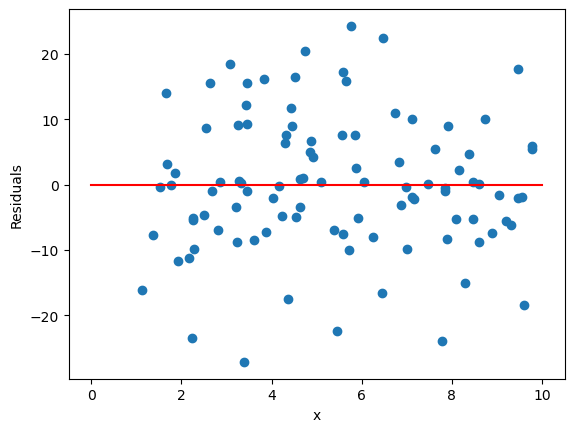

In [170]:
# Residual plot for original y option
scatter(x, y - ols_model_2.predict(x2_add_const ))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')

plt.show() 

# data set 3 
# Original Y
1. Create a scatter plot and found: 
    1. Non-linear Relationship: Y increases exponentially as X increases. Should apply a log or a square root  transformation to Y and see if the relationship becomes more linear.
    2. Distribution: The histograms for y shows extreme skewness which indicate non-linear relation. y has large values which are much higher than the median value, indicating positive skewness.
2. Carry out OLS regression model: Y need to be treated before fit the model, because:
    1. Skewness value 0.863	indicates moderate positive skewness in residuals, suggesting a longer right tail.
    2. Kurtosis 5.474	>3, it is not normal residual distribution
3. Residual plot NOT meets conditions
    1. NOT Homoscedasticity(NOT Constant variability):when x increase, the residual increase.
  
# Square root Y : I treat Y with both log and square root methods. After OLS model and residual plot, I concluded the data should use square root to treat y. 
1. After took square root for Y, OLS R-squared increased from 0.755 to 0.857, with Skew decrease to -0.657 and Kurtosis 3.7 close to 3.  
2. The residule plot of square root Y meet the Conditions for the least squares line:Linearity,Nearly normal residuals. But still with some tendency to increase residual when x increase.
3. An interpretation of the slope and intercept in relation to the original data: Intercept: -2.2001, Slope : 9.7861
    1. square root y Slope Interpretation:For every one-unit increase in ( x ), y square root is expected to increase by approximately 9.7861 units.
To interpret this in terms of the original ( y ), we need to consider the intercept. A function to calculate original_y_increase in below cell:
        1. when x increase from 0 to 1,  original y will increase around 96.
        2. when x increase from 1 to 2,  original y will increase around 244.
        3. when x increase from 2 to 3,  original y will increase around 436. 
    2. The intercept in the transformed model represents the expected value of ( y square root ) when ( x = 0 ). To interpret this in terms of the original ( y ), we square the intercept. When ( x = 0 ), the expected value of ( y ) is: (-2.2001)**2 = 4.8404 


In [198]:
#function to calculate original_y_increase
def original_y_increase (x1,x2):
    a1=-2.2001+9.7861*x1
    a2=-2.2001+9.7861*x2
    return a1, a2, a2**(2)-a1**(2)
    
original_y_increase (3,4)

(27.1582, 36.9443, 627.3134752499998)

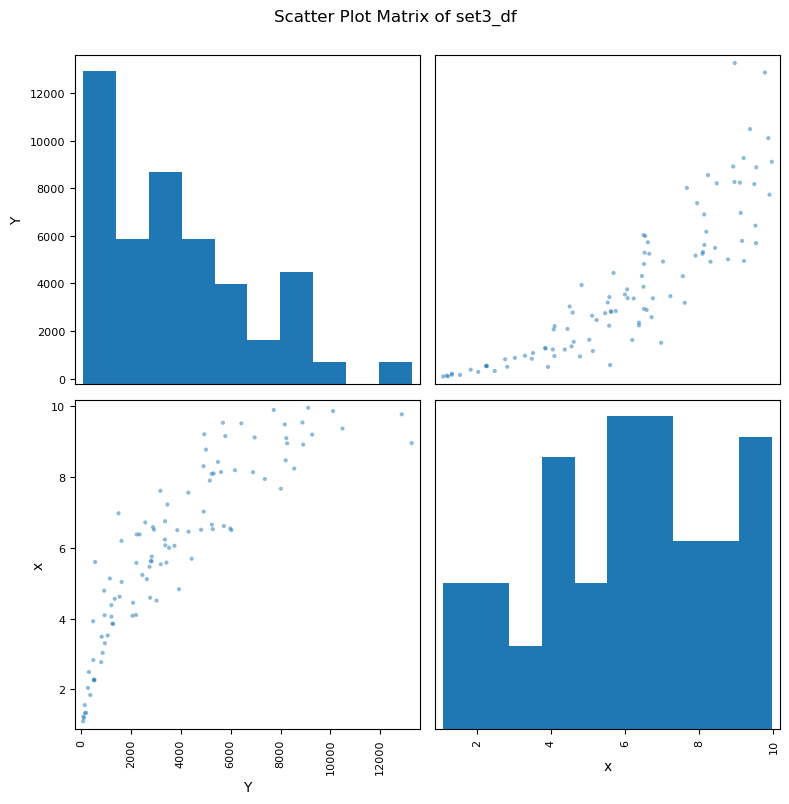

In [171]:
    scatter_matrix(set3_df, figsize=(8,8))
    plt.suptitle('Scatter Plot Matrix of set3_df', y=1) 
    plt.tight_layout()
    plt.show()

In [172]:
set3_df_tran=set3_df
set3_df_tran['log_y'] = set3_df_tran['Y'].apply(lambda a: np.log(a)) 
set3_df_tran['sqrt_y'] = set3_df_tran['Y'].apply(lambda a: np.sqrt(a)) 
set3_df_tran.head()

,Y,x,log_y,sqrt_y
0,6428.915770,9.517,8.768561,80.180520
1,2640.000728,5.113,7.878534,51.380937
2,12858.599267,9.773,9.461768,113.395764
3,5491.450053,8.428,8.610948,74.104319
4,2838.820108,5.752,7.951144,53.280579


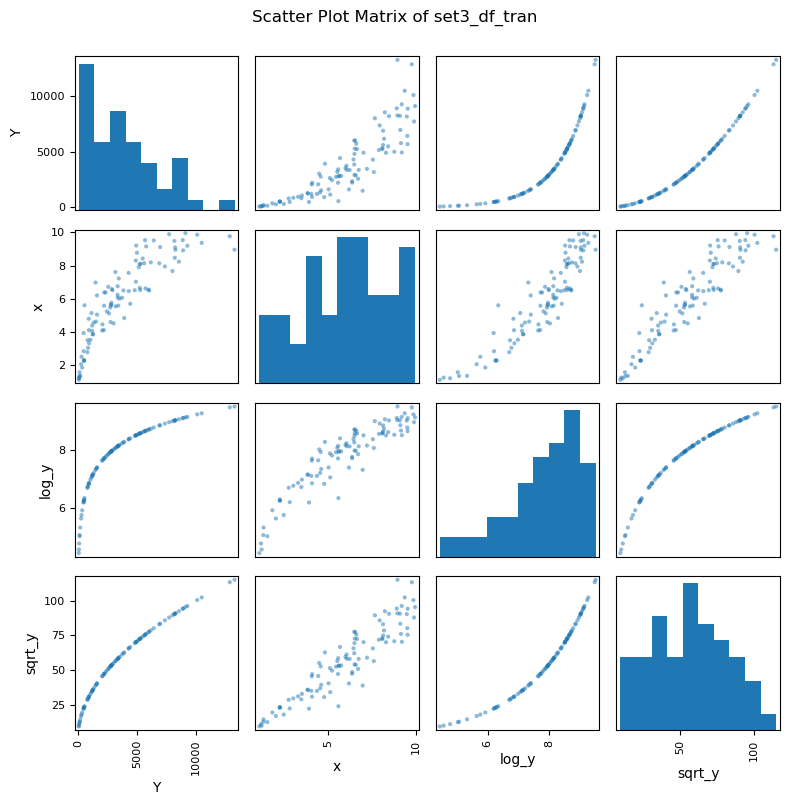

In [173]:
    scatter_matrix(set3_df_tran, figsize=(8,8))
    plt.suptitle('Scatter Plot Matrix of set3_df_tran', y=1) 
    plt.tight_layout()
    plt.show()

In [184]:
# OLS for original y option
import statsmodels.api as sm
x3 = set3_df_tran[['x']]
y3 = set3_df_tran['Y']

# Add a constant to the independent variables matrix for intercept
x3_add_cons = sm.add_constant(x3) # this add a constant of 1

# Fit OLS model
ols_model3_original = sm.OLS(y3, x3_add_cons).fit()

# model summary
ols_model3_original.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.755
Model:                            OLS   Adj. R-squared:                  0.753
Method:                 Least Squares   F-statistic:                     302.4
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           1.04e-31
Time:                        17:48:33   Log-Likelihood:                -873.07
No. Observations:                 100   AIC:                             1750.
Df Residuals:                      98   BIC:                             1755.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2636.1748    402.741     -6.546      0.000   -3435.400   -1836.949
x           1081.8266     62.216     17.388      0.000     958.361    1205.292
==============================================================================
Omnibus:                       21.170   Durbin-Watson:                   2.159
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.896
Skew:                           0.863   Prob(JB):                     5.90e-09
Kurtosis:                       5.474   Cond. No.                         17.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [182]:
# use sklearn to fit linear regression model and get coef and intercept for original y option
from sklearn.linear_model import LinearRegression

x3 = set3_df[['x']]
y3 = set3_df['Y']

ols_model3_original = sklearn.linear_model.LinearRegression().fit(x, y)
print(ols_model3_original.coef_)
print(ols_model3_original.intercept_)

[1081.8265912]
-2636.1748393061243


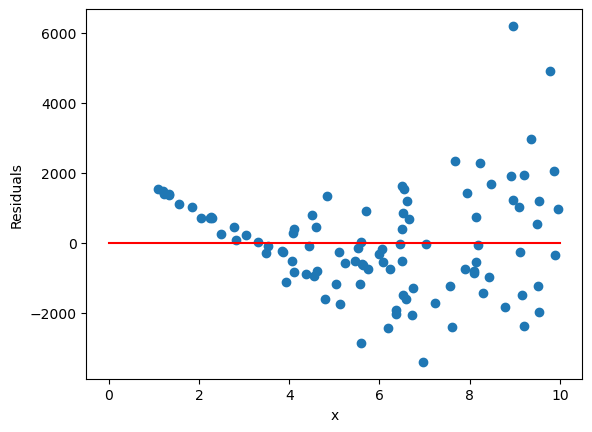

In [183]:
# Residual plot for original y option
scatter(x3, y3 - ols_model3_original.predict(x3))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')

plt.show() 

In [185]:
# OLS for log option
import statsmodels.api as sm
x = set3_df[['x']]
y = set3_df['log_y']

# Add a constant to the independent variables matrix for intercept
x = sm.add_constant(x) # this add a constant of 1

# Fit OLS model
ols_model_log = sm.OLS(y, x).fit()

# model summary
ols_model_log.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  log_y   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     519.7
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           5.82e-41
Time:                        17:49:25   Log-Likelihood:                -64.530
No. Observations:                 100   AIC:                             133.1
Df Residuals:                      98   BIC:                             138.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.1716      0.124     41.690      0.000       4.925       5.418
x              0.4368      0.019     22.796      0.000       0.399       0.475
==============================================================================
Omnibus:                        3.457   Durbin-Watson:                   2.007
Prob(Omnibus):                  0.178   Jarque-Bera (JB):                3.160
Skew:                          -0.435   Prob(JB):                        0.206
Kurtosis:                       3.014   Cond. No.                         17.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [186]:
# use sklearn to fit linear regression model and get coef and intercept
from sklearn.linear_model import LinearRegression

x = set3_df[['x']]
y = set3_df['log_y']

ols_model_log = sklearn.linear_model.LinearRegression().fit(x, y)
print(ols_model_log.coef_)
print(ols_model_log.intercept_)

[0.43684937]
5.171610738518249


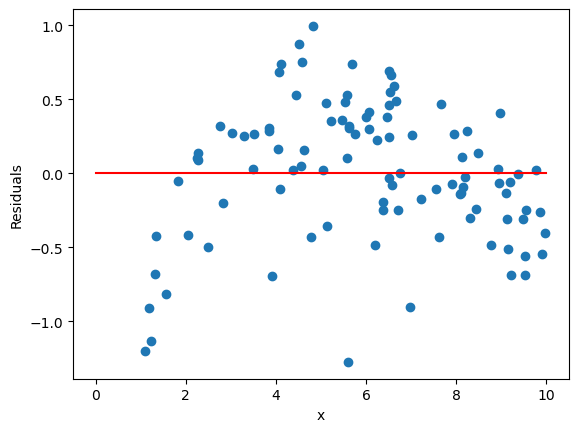

In [187]:
# Residual plot
scatter(x, y - ols_model_log.predict(x))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')

plt.show() 

In [191]:
# OLS for sqrt option
import statsmodels.api as sm
x = set3_df[['x']]
y = set3_df['sqrt_y']

# Add a constant to the independent variables matrix for intercept
x = sm.add_constant(x) # this add a constant of 1

# Fit OLS model
ols_model = sm.OLS(y, x).fit()

# model summary
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 sqrt_y   R-squared:                       0.857
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     588.0
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           3.37e-43
Time:                        18:02:14   Log-Likelihood:                -369.26
No. Observations:                 100   AIC:                             742.5
Df Residuals:                      98   BIC:                             747.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.2001      2.612     -0.842      0.402      -7.384       2.984
x              9.7861      0.404     24.249      0.000       8.985      10.587
==============================================================================
Omnibus:                        2.926   Durbin-Watson:                   1.892
Prob(Omnibus):                  0.232   Jarque-Bera (JB):                2.648
Skew:                          -0.150   Prob(JB):                        0.266
Kurtosis:                       3.739   Cond. No.                         17.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [192]:

from sklearn.linear_model import LinearRegression
x = set3_df[['x']]
y = set3_df['sqrt_y']

ols_model_sqrt = sklearn.linear_model.LinearRegression().fit(x, y)
print(ols_model_sqrt.coef_)
print(ols_model_sqrt.intercept_)


[9.78605648]
-2.2000878546593086


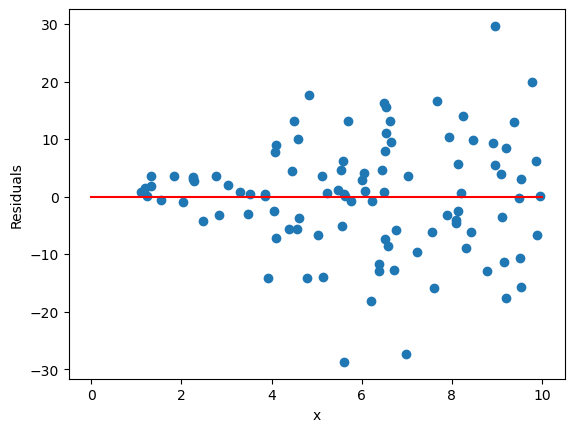

In [193]:
# Residual plot
scatter(x, y - ols_model_sqrt.predict(x))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')

plt.show() 

# data set 4 
1. Create a scatter plot and found: 
    1. Non-linear Relationship: Y increases exponentially as X increases. Applying a log transformation to Y and see if the relationship becomes more linear.
    2. Distribution: The histograms for y shows extreme skewness which indicate non-linear relation. y has large values which are much higher than the median value, indicating positive skewness.
2. Carry out OLS regression model. Compare orgininal Y and ln Y OLS
    1.  After took log for Y, OLS R-squared increased from original 0.380 to 0.982, with Skew decrease from 3.381 to -0.657 and Kurtosis decrease from 18.973 to around 3. 
3. Residual plot meets conditions after took ln Y. 
    1. Nearly normal residuals (randomly scattered):The residuals appear to be randomly scattered around the horizontal line at zero.This indicates that the linear regression model is appropriate for the data.
    2. Homoscedasticity(Constant variability):The residuals have constant variance across all levels of x.
    3. Linearity (No Obvious Patterns): There are no clear patterns, such as curvature or systematic structure, in the residuals.This suggests that there are no major issues with non-linearity.

4. An interpretation of the slope and intercept in relation to the original data: Intercept: 5.6647	, Slope : 0.9898 
    1. square root y Slope Interpretation:For every one-unit increase in ( x ), ln Y is expected to increase by approximately 0.9898 units.
To interpret this in terms of the original ( y ), a function to calculate original_y_increase in below cell:
        1. when x increase from 0 to 1,  original y will increase around 487.
        2. when x increase from 1 to 2,  original y will increase around 1312.
        3. when x increase from 2 to 3,  original y will increase around 3531. 
    2. The intercept in the transformed model represents the expected value of (ln y ) when ( x = 0 ). To interpret this in terms of the original ( y ), we power the intercept. When ( x = 0 ), the expected value of ( y ) is: e**(5.6647) = 288.5

In [216]:
#function to calculate original_y_increase
def original_y_increase (x1,x2):
    a1=5.6647+0.9898*x1
    a2=5.6647+0.9898*x2
    return a1, a2, np.exp(a2)-np.exp(a1)
    
original_y_increase (2,3)

(7.644299999999999, 8.6341, 3531.367411647101)

In [217]:
np.exp(5.6647)

288.5014177074408

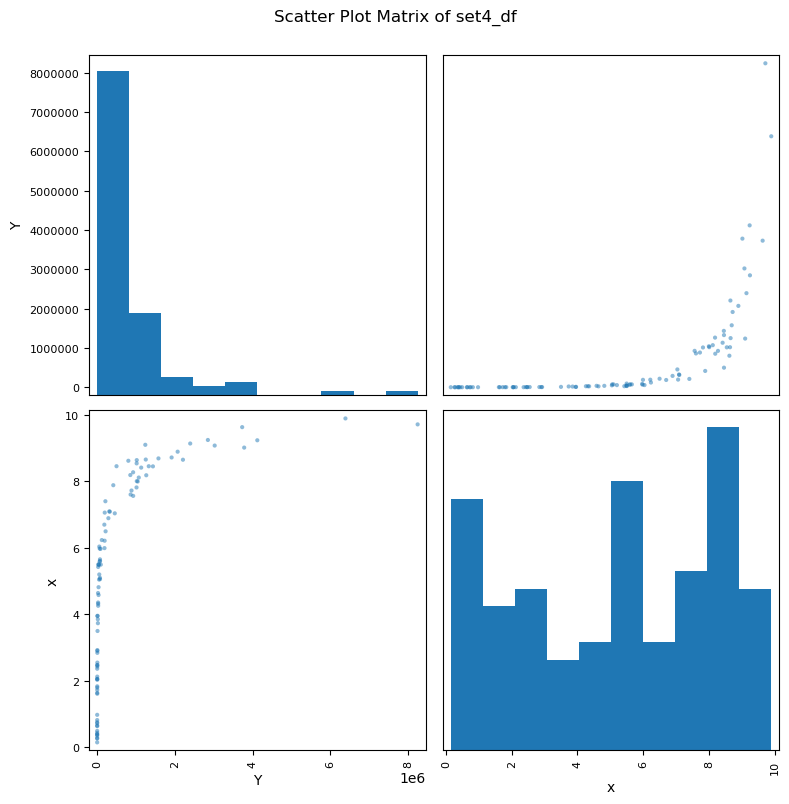

In [199]:
    scatter_matrix(set4_df, figsize=(8,8))
    plt.suptitle('Scatter Plot Matrix of set4_df', y=1) 
    plt.tight_layout()
    plt.show()

In [213]:

set4_df['log_y'] = set4_df['Y'].apply(lambda a: np.log(a)) # this is natural log; log10 is np.log10(a)
set4_df.head(10)

,Y,x,log_y
0,1.887192e+05,5.9947,12.148015
1,7.107264e+03,3.9492,8.868873
2,3.729064e+06,9.6353,15.131668
3,5.691779e+02,0.4943,6.344193
4,3.022130e+06,9.0811,14.921472
5,2.440908e+04,4.3569,10.102711
6,1.553813e+03,2.3649,7.348467
7,8.516838e+04,5.9698,11.352385
8,1.433694e+06,8.4548,14.175765
9,2.168963e+05,6.5002,12.287175


In [202]:
# OLS for original option
import statsmodels.api as sm
x4 = set4_df[['x']]
y4 = set4_df['Y']

# Add a constant to the independent variables matrix for intercept
x4 = sm.add_constant(x4) # this add a constant of 1

# Fit OLS model
ols_model4_original = sm.OLS(y4, x4).fit()

# model summary
ols_model4_original.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.373
Method:                 Least Squares   F-statistic:                     59.97
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           8.87e-12
Time:                        20:57:16   Log-Likelihood:                -1526.2
No. Observations:                 100   AIC:                             3056.
Df Residuals:                      98   BIC:                             3062.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -7.535e+05    2.1e+05     -3.585      0.001   -1.17e+06   -3.36e+05
x           2.707e+05   3.49e+04      7.744      0.000    2.01e+05     3.4e+05
==============================================================================
Omnibus:                      102.143   Durbin-Watson:                   2.077
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1253.666
Skew:                           3.381   Prob(JB):                    5.89e-273
Kurtosis:                      18.973   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [203]:
# OLS for log option
import statsmodels.api as sm
x4 = set4_df[['x']]
y4 = set4_df['log_y']

# Add a constant to the independent variables matrix for intercept
x4 = sm.add_constant(x4) # this add a constant of 1

# Fit OLS model
ols_model4_log = sm.OLS(y4, x4).fit()

# model summary
ols_model4_log.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  log_y   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.983
Method:                 Least Squares   F-statistic:                     5765.
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           6.91e-89
Time:                        20:57:24   Log-Likelihood:                -46.034
No. Observations:                 100   AIC:                             96.07
Df Residuals:                      98   BIC:                             101.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.6647      0.078     72.264      0.000       5.509       5.820
x              0.9898      0.013     75.930      0.000       0.964       1.016
==============================================================================
Omnibus:                        7.020   Durbin-Watson:                   2.151
Prob(Omnibus):                  0.030   Jarque-Bera (JB):                7.256
Skew:                          -0.657   Prob(JB):                       0.0266
Kurtosis:                       2.872   Cond. No.                         12.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [206]:

from sklearn.linear_model import LinearRegression
x4 = set4_df[['x']]
y4 = set4_df['log_y']

ols_model4_log = sklearn.linear_model.LinearRegression().fit(x4, y4)
print(ols_model4_log.coef_)
print(ols_model4_log.intercept_)

[0.9898482]
5.6647217612278595


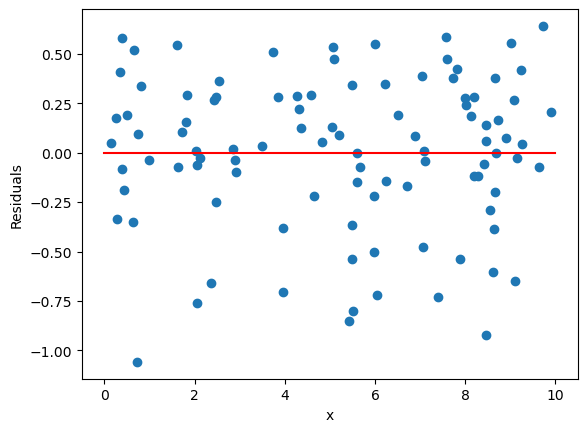

In [207]:
# Residual plot
scatter(x4, y4 - ols_model4_log.predict(x4))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')

plt.show() 

# data set 5

1. Create a scatter plot and found: 
    1. Linear Relationship: The scatter plot of x vs. y indicates a strong linear relationship.
    2. An outlier that lies far from the regression line but whose (X) and (Y) values are within the normal range. 
2. Indentify outlier Based on Residuals. Evaluate outlier type
    1. There is one outlier far from the cloud. However, it falls far away from the least squares line and appear to be influential.
3. Carry out OLS regression model. Compare orgininal data's and remove outlier data's OLS
    1. After took remove outlier for data, OLS R-squared increased from original 0.806 to 0.906, with much better Skew and Kurtosis.
    2. We can remove the outlier as the outlier is inflential to the least squares line (make it towards bottom) and the R-squared will improve if we remove the outlier. 

4. An interpretation of the slope and intercept in relation to the removed outlier data: Intercept: -0.0993, Slope : 5.0705
    1. Intercept Coefficient: -0.0993 p-value>0.5 The intercept is not statistically significant, suggesting it may not be different from zero.
    2. Slope Coefficient: 5.0705 p-value: 0.000  The slope coefficient is highly significant, indicating a strong linear relationship between x and y.
    3. The intercept is the estimated y when x takes value 0, i.e. when the x is 0. The average y is -0.0993 The slope indicates that, on average, when x increase 1, y increase about 5.0705. 

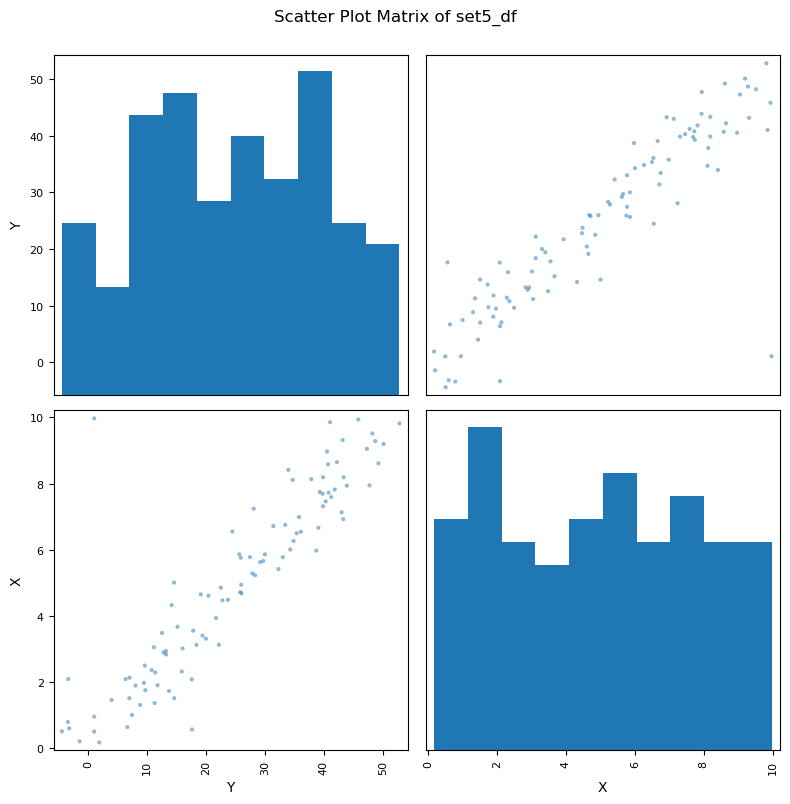

In [224]:
    scatter_matrix(set5_df, figsize=(8,8))
    plt.suptitle('Scatter Plot Matrix of set5_df', y=1) 
    plt.tight_layout()
    plt.show()

In [258]:
# OLS for original option
import statsmodels.api as sm
x5 = set5_df[['X']]
y5 = set5_df['Y']
x5_with_const = x5 
# Add a constant to the independent variables matrix for intercept
x5_with_const = sm.add_constant(x5_with_const) # this add a constant of 1

# Fit OLS model
ols_model5_original = sm.OLS(y5, x5_with_const).fit()

# model summary
ols_model5_original.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.804
Method:                 Least Squares   F-statistic:                     411.9
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           4.70e-37
Time:                        23:44:31   Log-Likelihood:                -334.42
No. Observations:                 101   AIC:                             672.8
Df Residuals:                      99   BIC:                             678.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9213      1.346      0.685      0.495      -1.749       3.591
X              4.7671      0.235     20.294      0.000       4.301       5.233
==============================================================================
Omnibus:                      113.783   Durbin-Watson:                   1.491
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2578.951
Skew:                          -3.591   Prob(JB):                         0.00
Kurtosis:                      26.691   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

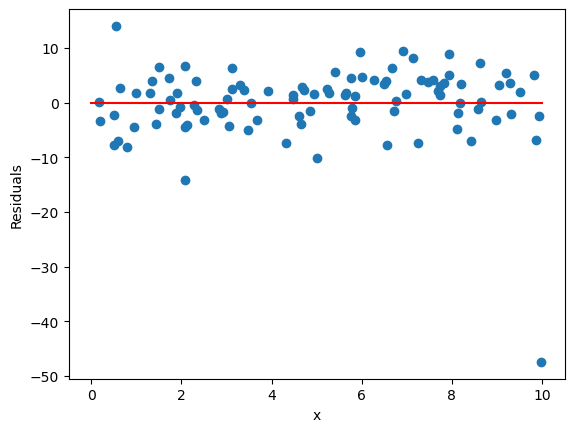

In [259]:
# Residual plot
scatter(x5, y5 - ols_model5_original.predict(x5_with_const))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')
plt.show() 

In [266]:
#identify by standard diviation of residuals and remove outlier
set5_df_remove_outlier=set5_df
residuals =y5- ols_model5_original.predict(x5_with_const)
set5_df_remove_outlier['residual']=residuals
std_residuals = np.std(residuals)
threshold = 3 * std_residuals
outliers = set5_df_remove_outlier[np.abs(set5_df_remove_outlier['residual']) > threshold]
set5_df_without_outlier = set5_df_remove_outlier[np.abs(set5_df_remove_outlier['residual']) <= threshold]
outliers

,Y,X,residual
100,1.03214,9.97071,-47.420297


In [264]:
# OLS for without outlier option
import statsmodels.api as sm
x5_r = set5_df_without_outlier[['X']]
y5_r = set5_df_without_outlier['Y']
x5_with_const_r = x5_r 
# Add a constant to the independent variables matrix for intercept
x5_with_const_r = sm.add_constant(x5_with_const_r) # this add a constant of 1

# Fit OLS model
ols_model5_without_outlier = sm.OLS(y5_r, x5_with_const_r).fit()

# model summary
ols_model5_without_outlier.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      Y   R-squared:                       0.906
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                     945.8
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           3.84e-52
Time:                        23:47:03   Log-Likelihood:                -294.13
No. Observations:                 100   AIC:                             592.3
Df Residuals:                      98   BIC:                             597.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0993      0.935     -0.106      0.916      -1.954       1.756
X              5.0705      0.165     30.753      0.000       4.743       5.398
==============================================================================
Omnibus:                        3.022   Durbin-Watson:                   1.918
Prob(Omnibus):                  0.221   Jarque-Bera (JB):                2.760
Skew:                          -0.158   Prob(JB):                        0.252
Kurtosis:                       3.750   Cond. No.                         11.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

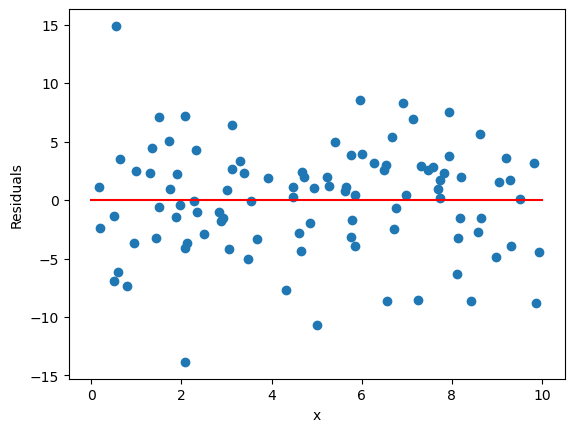

In [265]:
# Residual plot
scatter(x5_r, y5_r - ols_model5_without_outlier.predict(x5_with_const_r))
plt.xlabel("x")
plt.ylabel("Residuals")
plt.plot([0, 10], [0, 0], 'r-')
plt.show() 

# data set 6 

1. Create a scatter plot and found: 
    1. Linear Relationship: The scatter plot of x vs. y indicates a strong linear relationship, which is ideal for linear regression.
    2. Outlier: The histograms for both x and y show their respective distributions. They shows there is a outlier row. 
2. Indentify outlier and outlier type
    1. There is one outlier far from the cloud. However, it falls quite close to the least squares line and does not appear to be very influential.
3. Carry out OLS regression model. Compare orgininal data and remove outlier data OLS
    1.  After took remove outlier for data, OLS R-squared decreased from original 0.913 to 0.837, with Skew and Kurtosis not change much. 
    2. We can keep the outlier as it is almost on the least squares line and impprove the R-squared. 

4. An interpretation of the slope and intercept in relation to the original data: Intercept: -0.3059	, Slope : 7.0272
    1. Intercept Coefficient: -0.3059 p-value>0.5 The intercept is not statistically significant, suggesting it may not be different from zero.
    2. Slope Coefficient: 7.0272 p-value: 0.000  The slope coefficient is highly significant, indicating a strong linear relationship between x and y.
    3. The intercept is the estimated y when x takes value 0, i.e. when the x is 0. The average y is -0.3059 The slope indicates that, on average, when x increase 1, y increase about 7.0272. 

In [133]:
set6_df.describe()

,y,x
count,101.000000,101.000000
mean,39.178208,5.618743
std,31.390864,4.268607
min,-6.757358,0.111800
25%,19.890518,2.539300
50%,39.493906,5.446000
75%,56.813645,8.108500
max,252.837897,35.783400


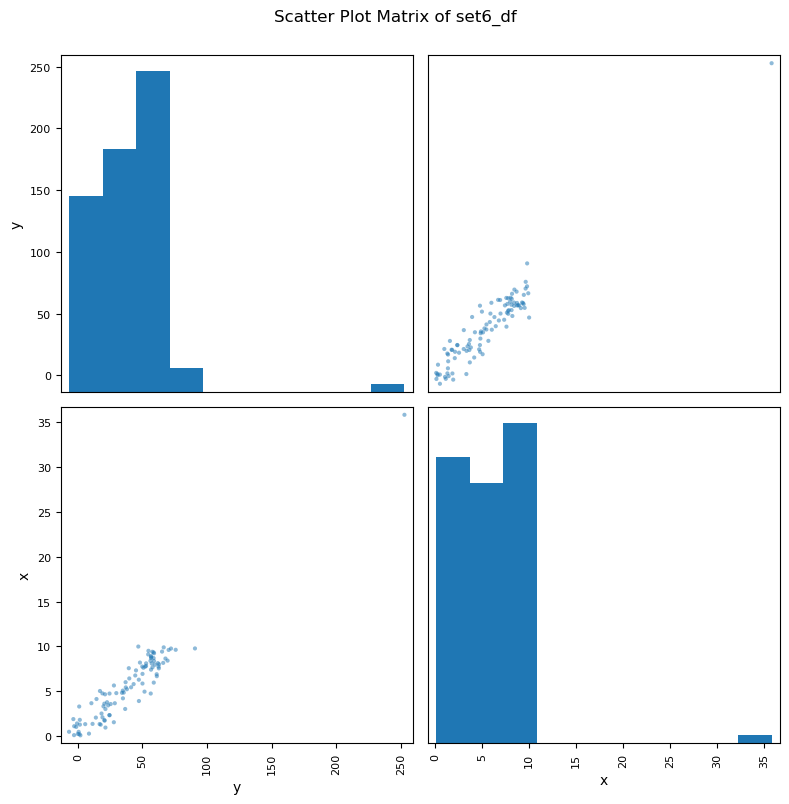

In [218]:
    scatter_matrix(set6_df, figsize=(8,8))
    plt.suptitle('Scatter Plot Matrix of set6_df', y=1) 
    plt.tight_layout()
    plt.show()

In [132]:
from scipy import stats
z_scores = np.abs(stats.zscore(set6_df['y']))
z_scores

0      1.342819
1      0.700735
2      0.437853
3      1.346540
4      0.636055
         ...   
96     0.560809
97     0.997728
98     0.588644
99     0.635181
100    6.840377
Name: y, Length: 101, dtype: float64

In [144]:
outlier_mask = (z_scores > 3)
outlier_rows = set6_df[outlier_mask] #uses the boolean mask to filter the rows in set6_df
outlier_rows


,y,x
100,252.837897,35.7834


In [219]:
outlier_mask_keep = (z_scores <= 3)
set6_df_remove_outlier = set6_df[outlier_mask_keep] #uses the boolean mask to filter the rows in set6_df
set6_df_remove_outlier

,y,x
0,-2.764835,1.1290
1,61.065734,6.9100
2,52.854588,7.8374
3,-2.881062,0.1335
4,59.045448,9.2425
...,...,...
95,57.886726,7.6842
96,56.695106,8.7167
97,70.342334,9.6165
98,20.791865,1.7477


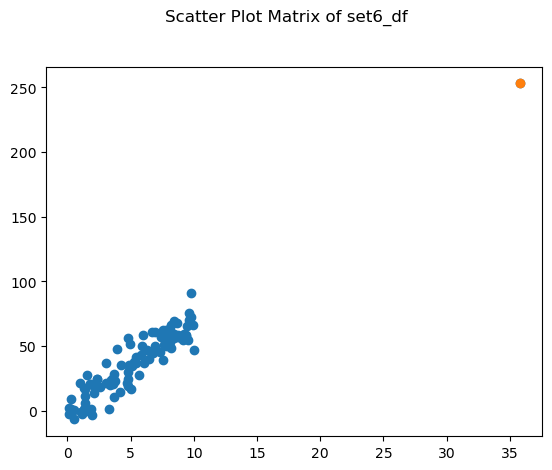

In [145]:

plt.scatter(set6_df['x'],set6_df['y'])
plt.scatter(outlier_rows['x'],outlier_rows['y'])
plt.suptitle('Scatter Plot Matrix of set6_df', y=1) 
plt.show()

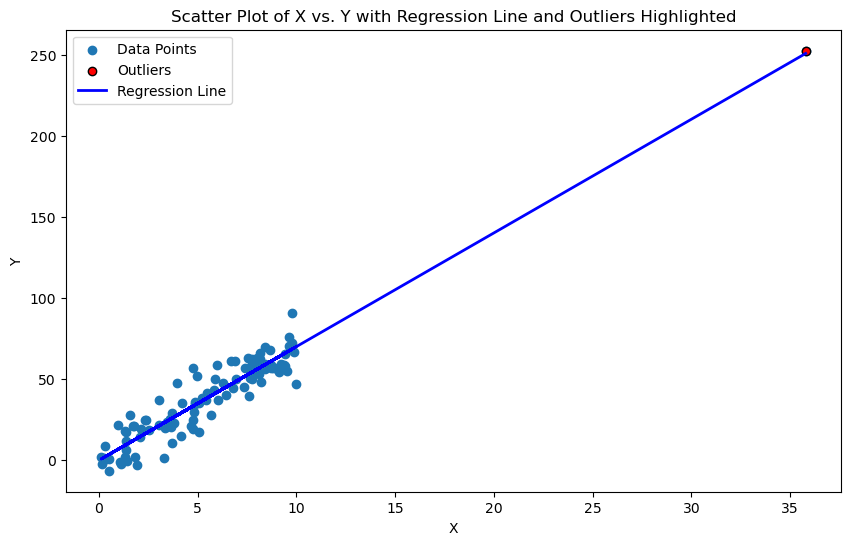

Intercept: -0.3059107436463293
Coefficient: 7.027216147378344


In [150]:
# Define independent variable X and dependent variable Y
X = set6_df[['x']].values.reshape(-1, 1) #scikit-learn expects this feature to be in a 2D array with shape (n_samples, n_features).
Y = set6_df['y']

# Fit the linear regression model using scikit-learn
model = LinearRegression()
model.fit(X, Y)

# Make predictions based on the model for plotting the regression line
y_pred = model.predict(X)

# Plotting the data with outliers highlighted and regression line added
plt.figure(figsize=(10, 6))
plt.scatter(set6_df['x'], set6_df['y'], label='Data Points')
plt.scatter(outlier_rows['x'], outlier_rows['y'], color='r', edgecolor='k', label='Outliers')
plt.plot(set6_df['x'], y_pred, color='blue', linewidth=2, label='Regression Line')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Scatter Plot of X vs. Y with Regression Line and Outliers Highlighted')
plt.legend()
plt.show()

# Print the coefficients of the linear regression model
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")

In [221]:

# OLS for original option
import statsmodels.api as sm
x6 = set6_df[['x']]
y6 = set6_df['y']

# Add a constant to the independent variables matrix for intercept
x6 = sm.add_constant(x6) # this add a constant of 1

# Fit OLS model
ols_model6 = sm.OLS(y6, x6).fit()

# model summary
ols_model6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.913
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                     1041.
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           2.49e-54
Time:                        21:40:52   Log-Likelihood:                -367.52
No. Observations:                 101   AIC:                             739.0
Df Residuals:                      99   BIC:                             744.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3059      1.534     -0.199      0.842      -3.350       2.739
x              7.0272      0.218     32.259      0.000       6.595       7.459
==============================================================================
Omnibus:                        0.494   Durbin-Watson:                   2.255
Prob(Omnibus):                  0.781   Jarque-Bera (JB):                0.262
Skew:                           0.120   Prob(JB):                        0.877
Kurtosis:                       3.070   Cond. No.                         11.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [223]:

# OLS for original option
import statsmodels.api as sm
x6_r = set6_df_remove_outlier[['x']]
y6_r = set6_df_remove_outlier['y']

# Add a constant to the independent variables matrix for intercept
x6_r = sm.add_constant(x6_r) # this add a constant of 1

# Fit OLS model
ols_model6_r = sm.OLS(y6_r, x6_r).fit()

# model summary
ols_model6_r.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     502.7
Date:                Sat, 19 Jul 2025   Prob (F-statistic):           2.29e-40
Time:                        21:42:38   Log-Likelihood:                -364.34
No. Observations:                 100   AIC:                             732.7
Df Residuals:                      98   BIC:                             737.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0203      1.899     -0.011      0.991      -3.788       3.748
x              6.9703      0.311     22.420      0.000       6.353       7.587
==============================================================================
Omnibus:                        0.459   Durbin-Watson:                   2.259
Prob(Omnibus):                  0.795   Jarque-Bera (JB):                0.261
Skew:                           0.123   Prob(JB):                        0.877
Kurtosis:                       3.044   Cond. No.                         12.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""